# NeuralForecast with synthetic data

This guide compares four leakage-safe workflows on the same M4 Monthly holdout: training on observed data, training on observed plus augmented data, zero-shot forecasting after pretraining only on independent synthetic series, and synthetic pretraining followed by fine-tuning on observed data.

We use a fixed, stratified sample of 24 series from the [M4 competition dataset](https://github.com/Mcompetitions/M4-methods), with four series from each domain category. Every selected training series has between 96 and 180 monthly observations. Evaluation uses the official 18-month M4 test horizon.

The sample was drawn once with seed 42 from eligible M4 Monthly series. The data is downloaded from the official repository when this notebook is executed and is not redistributed with SynForecast. See Makridakis, Spiliotis, and Assimakopoulos, [*The M4 Competition: 100,000 time series and 61 forecasting methods*](https://doi.org/10.1016/j.ijforecast.2019.04.014).

In [ ]:
import csv
import tempfile
from functools import partial
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mase, smape

from synforecast import SynAugment, generate_series
from synforecast.generators import ETSGenerator, SARIMAGenerator, SeasonalGenerator

In [ ]:
HORIZON = 18
SEASON_LENGTH = 12
TARGET_IDS = [
    "M21522", "M21345", "M23456", "M22325",  # Demographic
    "M41442", "M40386", "M39368", "M39192",  # Finance
    "M35069", "M27603", "M27586", "M29021",  # Industry
    "M4433", "M4489", "M7650", "M8464",      # Macro
    "M10215", "M14927", "M11649", "M15420",  # Micro
    "M47985", "M47988", "M47930", "M47841",  # Other
]

M4_BASE_URL = "https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset"
CACHE_DIR = Path(tempfile.gettempdir()) / "synforecast-m4"
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def download_m4_split(split: str) -> Path:
    path = CACHE_DIR / f"Monthly-{split.lower()}.csv"
    if not path.exists():
        urlretrieve(f"{M4_BASE_URL}/{split}/Monthly-{split.lower()}.csv", path)
    return path


def load_selected_series(
    path: Path, start_at: dict[str, int] | None = None
) -> pd.DataFrame:
    records = []
    with path.open(newline="") as file:
        reader = csv.reader(file)
        next(reader)
        for row in reader:
            unique_id = row[0]
            if unique_id not in TARGET_IDS:
                continue
            values = [float(value) for value in row[1:] if value]
            start = 1 if start_at is None else start_at[unique_id]
            records.extend(
                (unique_id, start + offset, value)
                for offset, value in enumerate(values)
            )
    return pd.DataFrame(records, columns=["unique_id", "ds", "y"])


train_df = load_selected_series(download_m4_split("Train"))
test_starts = (
    train_df.groupby("unique_id", observed=True)["ds"].max().add(1).to_dict()
)
test_df = load_selected_series(download_m4_split("Test"), test_starts)

pd.DataFrame(
    {
        "series": [train_df["unique_id"].nunique()],
        "minimum training length": [train_df.groupby("unique_id").size().min()],
        "maximum training length": [train_df.groupby("unique_id").size().max()],
        "holdout length": [test_df.groupby("unique_id").size().min()],
    }
)

,series,minimum training length,maximum training length,holdout length
0,24,102,180,18


For the augmentation workflow, `SynAugment` fits each training series independently and creates candidate counterparts. We retain one counterpart from each of the six M4 domain categories, so synthetic series make up only 20% of the combined panel instead of half of it. This category-balanced ratio is fixed before evaluation, and the official holdout is never passed to the augmenter.

For synthetic pretraining, we deliberately avoid the generic balanced pool. The custom pool below contains monthly SARIMA, ETS, and seasonal processes with 12-step seasonality and training lengths comparable to the selected M4 histories. These synthetic series are generated independently of both the M4 training observations and the holdout.

In [ ]:
augmented_train_df = SynAugment(seed=42).augment(train_df, n_augment=1)
selected_source_ids = TARGET_IDS[::4]  # One from each M4 domain category
selected_augmentation_ids = {
    f"{unique_id}_aug_0" for unique_id in selected_source_ids
}
selected_augmentations = augmented_train_df.loc[
    augmented_train_df["unique_id"].astype(str).isin(selected_augmentation_ids)
].copy()
augmented_train_df = pd.concat(
    [train_df, selected_augmentations], ignore_index=True
)

monthly_generators = [
    SARIMAGenerator(
        min_length=96,
        max_length=180,
        freq=1,
        engine="polars",
        seasonal_period=12,
        d=1,
        D=1,
        noise_std=2.0,
        seed=1,
    ),
    SARIMAGenerator(
        min_length=96,
        max_length=180,
        freq=1,
        engine="polars",
        seasonal_period=12,
        p=2,
        q=0,
        P=0,
        Q=1,
        noise_std=1.5,
        seed=2,
    ),
    ETSGenerator(
        min_length=96,
        max_length=180,
        freq=1,
        engine="polars",
        seasonal_period=12,
        level=100.0,
        trend=0.2,
        noise_std=2.0,
        seed=3,
    ),
    ETSGenerator(
        min_length=96,
        max_length=180,
        freq=1,
        engine="polars",
        seasonal_period=12,
        level=50.0,
        trend=-0.05,
        noise_std=1.0,
        damped=True,
        seed=4,
    ),
    SeasonalGenerator(
        min_length=96,
        max_length=180,
        freq=1,
        engine="polars",
        seasonality_period=12,
        seasonality_amplitude=10.0,
        trend=0.15,
        noise_level=2.0,
        seed=5,
    ),
    SeasonalGenerator(
        min_length=96,
        max_length=180,
        freq=1,
        engine="polars",
        seasonality_period=12,
        seasonality_amplitude=5.0,
        trend=-0.05,
        noise_level=1.0,
        seed=6,
    ),
]
synthetic_pretrain_df = pd.DataFrame(
    generate_series(n_series=96, generators=monthly_generators).to_dicts()
)
valid_ids = synthetic_pretrain_df.groupby("unique_id", observed=True)["y"].apply(
    lambda values: np.isfinite(values).all()
)
synthetic_pretrain_df = synthetic_pretrain_df.loc[
    synthetic_pretrain_df["unique_id"].isin(valid_ids[valid_ids].index)
].copy()

pd.DataFrame(
    {
        "training set": [
            "observed only",
            "observed + augmented",
            "independent synthetic only",
        ],
        "series": [
            train_df["unique_id"].nunique(),
            augmented_train_df["unique_id"].nunique(),
            synthetic_pretrain_df["unique_id"].nunique(),
        ],
        "observations": [
            len(train_df),
            len(augmented_train_df),
            len(synthetic_pretrain_df),
        ],
    }
)

,training set,series,observations
0,observed only,24,3533
1,observed + augmented,30,4498
2,independent synthetic only,96,13512


In [ ]:
def make_forecaster() -> NeuralForecast:
    torch.set_float32_matmul_precision("medium")
    model = NHITS(
        h=HORIZON,
        input_size=36,
        scaler_type="standard",
        val_check_steps=25,
        random_seed=42,
        max_steps=100,
        logger=False,
        enable_checkpointing=False,
        enable_model_summary=False,
        enable_progress_bar=False,
    )
    return NeuralForecast(models=[model], freq=1)


def target_forecast(forecast_df: pd.DataFrame) -> pd.DataFrame:
    return forecast_df.loc[
        forecast_df["unique_id"].astype(str).isin(TARGET_IDS),
        ["unique_id", "ds", "NHITS"],
    ].copy()

In [ ]:
real_only = make_forecaster()
real_only.fit(df=train_df)
real_only_forecast = target_forecast(real_only.predict())

/home/osprangers/Repositories/synforecast/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


/home/osprangers/Repositories/synforecast/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


In [ ]:
with_augmentation = make_forecaster()
with_augmentation.fit(df=augmented_train_df)
augmented_forecast = target_forecast(with_augmentation.predict())

/home/osprangers/Repositories/synforecast/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


/home/osprangers/Repositories/synforecast/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


For genuine pretraining, the next model sees only independently generated monthly series. `predict(df=train_df)` then applies those learned weights to the previously unseen M4 panel. Calling `fit` again with `use_init_models=False` retains the pretrained weights and fine-tunes them on the observed training split.

In [ ]:
pretrained = make_forecaster()
pretrained.fit(df=synthetic_pretrain_df)
zero_shot_forecast = target_forecast(pretrained.predict(df=train_df))

pretrained.fit(df=train_df, use_init_models=False)
finetuned_forecast = target_forecast(pretrained.predict())

/home/osprangers/Repositories/synforecast/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


/home/osprangers/Repositories/synforecast/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


/home/osprangers/Repositories/synforecast/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


We report the mean sMAPE and seasonal MASE across series, giving each M4 series equal weight. MASE uses each series' in-sample 12-month seasonal-naive error as its scale.

In [ ]:
forecast_sets = {
    "Observed only": real_only_forecast,
    "Observed + synthetic": augmented_forecast,
    "Synthetic pretraining (zero-shot)": zero_shot_forecast,
    "Synthetic pretraining + fine-tuning": finetuned_forecast,
}
comparison = test_df[["unique_id", "ds", "y"]].copy()
for label, forecast_df in forecast_sets.items():
    comparison = comparison.merge(
        forecast_df.rename(columns={"NHITS": label}),
        on=["unique_id", "ds"],
        how="left",
        validate="one_to_one",
    )

metrics = evaluate(
    df=comparison,
    metrics=[smape, partial(mase, seasonality=SEASON_LENGTH)],
    models=list(forecast_sets),
    train_df=train_df,
)
metrics = (
    metrics.groupby("metric", observed=True)[list(forecast_sets)]
    .mean()
    .T.rename_axis("workflow")
    .reset_index()
    .rename(columns={"smape": "sMAPE", "mase": "MASE"})
    .sort_values("MASE")
)
metrics = metrics[["workflow", "sMAPE", "MASE"]]
metrics

metric,workflow,sMAPE,MASE
1,Observed + synthetic,0.062056,0.895474
0,Observed only,0.064493,0.906638
3,Synthetic pretraining + fine-tuning,0.063916,0.907407
2,Synthetic pretraining (zero-shot),0.092384,1.347643


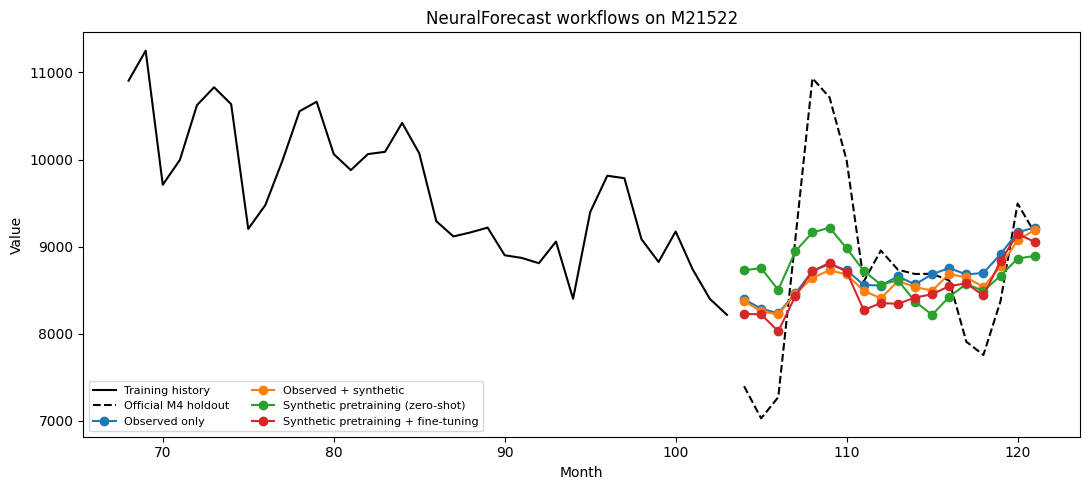

In [ ]:
plot_id = TARGET_IDS[0]
history = train_df.loc[train_df["unique_id"] == plot_id].tail(36)
holdout = comparison.loc[comparison["unique_id"] == plot_id]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(history["ds"], history["y"], color="black", label="Training history")
ax.plot(
    holdout["ds"],
    holdout["y"],
    color="black",
    linestyle="--",
    label="Official M4 holdout",
)
for label in forecast_sets:
    ax.plot(holdout["ds"], holdout[label], marker="o", label=label)
ax.set(title=f"NeuralForecast workflows on {plot_id}", xlabel="Month", ylabel="Value")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()

The conservative, category-balanced augmentation adds diversity without allowing generated histories to dominate the observed panel. Synthetic-only zero-shot forecasting remains the hardest setting, while fine-tuning adapts the pretrained model to the target domain.

These scores illustrate the workflow, not an M4 benchmark: the sample and neural model are intentionally small, each fit uses only 100 optimization steps, and results can vary with the selected panel. For a model comparison, evaluate all M4 Monthly series over multiple seeds and report uncertainty. Choose augmentation ratios using validation data, and never fit `SynAugment` on the official holdout.

For a rigorous, multi-seed look at whether augmentation actually improves accuracy — and an honest account of when it does not — see [When does synthetic data help?](../capabilities/when_synthetic_helps).